# 52 — LSEG/Gemma hybrid liquidity-aware sizing

**Candidate framing:** LSEG/Gemma semantic event selection with FinBERT ranking
and one analytically derived implementation rule.

Notebook 51 showed that the frozen equal-weight hybrid remains positive at a
conservative $10m impact scenario but fails by $25m. This notebook changes only
the magnitudes assigned to already selected names. Within each unchanged long and
short leg, the from-flat square-root impact objective has the convex solution

$$w_i \propto \frac{ADV_i}{\max(\sigma_i, 0.005)^2},$$

followed by deterministic water filling at the existing 25% name cap. Gemma still
determines the exact event dates and counts; FinBERT still determines every selected
name and sign; leg budgets, dollar neutrality, the one-session horizon, and fixed cost
remain unchanged.

The complete rule and stop conditions were frozen in
`frozen_specs/lseg_gemma_hybrid_liquidity_sizing_v1.json` before modified target
returns were calculated. The opened LSEG outcome window motivated this diagnostic,
so even a pass is implementation evidence rather than alpha confirmation.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from statsmodels.stats.multitest import multipletests

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.capacity import (  # noqa: E402
    ImpactConfig,
    build_lagged_liquidity,
    fold_terminal_liquidation,
    minimize_square_root_impact_weights,
    simulate_square_root_impact,
    square_root_impact_proxy,
    summarize_capacity,
)
from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import build_exact_extrema_targets  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    PositionTarget,
    TargetPortfolio,
)

SEED = 20260814
COST_BPS = 10.0
SINGLE_NAME_CAP = 0.25
VOLATILITY_FLOOR = 0.005
LIQUIDITY_WINDOW = 20
LIQUIDITY_MINIMUM_OBSERVATIONS = 5
PARTICIPATION_LIMIT = 0.05
IMPACT_COEFFICIENT = 1.0
PRIMARY_AUM = 10_000_000.0
EXTENSION_AUM = 25_000_000.0
EVALUATION_AUM = (PRIMARY_AUM, EXTENSION_AUM)
IMPACT_SCENARIOS = (0.0, IMPACT_COEFFICIENT)
BLOCK_LENGTH = 5
REPLICATIONS = 9_999
INPUT_TOLERANCE = 1e-12

AGGREGATE_DIR = REPO_ROOT / "final_experiments/outputs/13_lseg_44_gemma_robustness"
GEMMA_PATH = AGGREGATE_DIR / "gemma4_26b_firm_open_aggregators.parquet"
FINBERT_PATH = AGGREGATE_DIR / "finbert_firm_open_aggregators.parquet"
PRICE_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
N51_CURVE_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/51_lseg_gemma_hybrid_implementation_capacity/capacity_curve.csv"
)
FROZEN_SPEC_PATH = (
    REPO_ROOT
    / "final_experiments/frozen_specs/lseg_gemma_hybrid_liquidity_sizing_v1.json"
)
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/52_lseg_gemma_hybrid_liquidity_aware_sizing"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

apply_house_style()
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Frozen rule and return-blind feasibility gate

The impact objective is exact for entries from flat; it is only a proxy for drifted
rebalances. For that reason the rule is not allowed to see its modified forward
returns unless two aggregate conditions both hold: the from-flat objective falls and
target-path L1 turnover (including entry and exit) does not rise. Every selected
name/sign and every session's original long/short budget must also remain identical.

Only aggregate Gemma/FinBERT firm-open signals and lagged market inputs are used in
this section. No selected portfolio's next-open return is constructed or inspected.

In [2]:
frozen_spec = json.loads(FROZEN_SPEC_PATH.read_text())
assert frozen_spec["status"] == "frozen_before_modified_target_returns"
assert frozen_spec["outcome_evaluation_if_input_gate_passes"]["primary_initial_aum_usd"] == int(
    PRIMARY_AUM
)
assert (
    frozen_spec["outcome_evaluation_if_input_gate_passes"][
        "capacity_extension_initial_aum_usd"
    ]
    == int(EXTENSION_AUM)
)
assert frozen_spec["outcome_evaluation_if_input_gate_passes"]["impact_coefficient_Y"] == 1.0

sector_members = {sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()}
original_symbols = tuple(symbol for members in sector_members.values() for symbol in members)
gemma = pd.read_parquet(GEMMA_PATH)
finbert = pd.read_parquet(FINBERT_PATH)
for frame in (gemma, finbert):
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
gemma = gemma.loc[gemma["symbol"].isin(original_symbols)].copy()
finbert = finbert.loc[finbert["symbol"].isin(original_symbols)].copy()
if not gemma[["session_date", "symbol"]].equals(finbert[["session_date", "symbol"]]):
    raise ValueError("paired scorer panels are not row-aligned")
if gemma.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate scorer rows")
if finbert["strongest_event"].isna().any():
    raise ValueError("FinBERT ranks must be complete")

prices = pd.read_csv(PRICE_PATH, parse_dates=["session_date"])
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
prices = prices.loc[prices["symbol"].isin(original_symbols)].copy()
liquidity = build_lagged_liquidity(
    prices,
    window_sessions=LIQUIDITY_WINDOW,
    minimum_observations=LIQUIDITY_MINIMUM_OBSERVATIONS,
)
adv_wide = liquidity.pivot(index="session_date", columns="symbol", values="adv20_usd")
sigma_wide = liquidity.pivot(index="session_date", columns="symbol", values="sigma20")
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = tuple(sorted(gemma["symbol"].unique()))
if len(sessions) != 167 or set(symbols) != set(original_symbols):
    raise ValueError("expected 167 sessions and immutable original 33")


def rank_map(
    frame: pd.DataFrame,
    ordered_symbols: tuple[str, ...],
) -> dict[pd.Timestamp, tuple[str, ...]]:
    result = {
        pd.Timestamp(session): tuple(
            day.sort_values(
                ["strongest_event", "symbol"],
                ascending=[False, True],
                kind="mergesort",
            )["symbol"]
        )
        for session, day in frame.groupby("session_date", sort=True)
    }
    expected = set(ordered_symbols)
    if len(result) != len(sessions) or any(set(row) != expected for row in result.values()):
        raise ValueError("rank map is incomplete or has the wrong universe")
    return result


def portfolio(
    session: pd.Timestamp,
    ordered_symbols: tuple[str, ...],
    weights: dict[str, float],
) -> TargetPortfolio:
    vector = np.asarray([weights[symbol] for symbol in ordered_symbols], dtype=float)
    positions = tuple(
        PositionTarget(
            symbol=symbol,
            action=float(np.sign(weights[symbol])),
            volatility=None,
            raw_weight=weights[symbol],
            target_weight=weights[symbol],
            exclusion_reason=None,
        )
        for symbol in ordered_symbols
    )
    return TargetPortfolio(
        session=str(session.date()),
        positions=positions,
        gross_exposure=float(np.abs(vector).sum()),
        net_exposure=float(vector.sum()),
        long_exposure=float(vector[vector > 0].sum()),
        short_exposure=float(-vector[vector < 0].sum()),
        cash_weight=1.0 - float(vector.sum()),
    )


def build_target_pair() -> tuple[
    tuple[TargetPortfolio, ...],
    tuple[TargetPortfolio, ...],
    pd.DataFrame,
]:
    _, extrema_audit = build_exact_extrema_targets(
        gemma,
        single_name_cap=SINGLE_NAME_CAP,
    )
    ranks = rank_map(finbert, symbols)
    equal_targets: list[TargetPortfolio] = []
    optimized_targets: list[TargetPortfolio] = []
    audit_rows: list[dict[str, object]] = []
    for row in extrema_audit.itertuples(index=False):
        session = pd.Timestamp(row.session_date)
        n_long = int(row.positive_names)
        n_short = int(row.negative_names)
        eligible = bool(row.eligible)
        ranked = ranks[session]
        long_symbols = tuple(ranked[:n_long]) if eligible else ()
        short_symbols = tuple(ranked[-n_short:]) if eligible else ()
        if eligible and (not long_symbols or not short_symbols or set(long_symbols) & set(short_symbols)):
            raise RuntimeError("invalid hybrid rank selection")
        leg_exposure = (
            min(0.5, SINGLE_NAME_CAP * n_long, SINGLE_NAME_CAP * n_short)
            if eligible
            else 0.0
        )
        equal_weights = {symbol: 0.0 for symbol in symbols}
        if eligible:
            for symbol in long_symbols:
                equal_weights[symbol] = leg_exposure / n_long
            for symbol in short_symbols:
                equal_weights[symbol] = -leg_exposure / n_short

        selected = (*long_symbols, *short_symbols)
        selected_adv = {
            symbol: float(adv_wide.loc[session, symbol]) for symbol in selected
        }
        selected_sigma = {
            symbol: float(sigma_wide.loc[session, symbol]) for symbol in selected
        }
        inputs_complete = bool(
            all(np.isfinite(value) and value > 0 for value in selected_adv.values())
            and all(np.isfinite(value) and value >= 0 for value in selected_sigma.values())
        )
        optimized_weights = {symbol: 0.0 for symbol in symbols}
        if eligible and inputs_complete:
            long_magnitudes = minimize_square_root_impact_weights(
                {symbol: selected_adv[symbol] for symbol in long_symbols},
                {symbol: selected_sigma[symbol] for symbol in long_symbols},
                total_weight=leg_exposure,
                single_name_cap=SINGLE_NAME_CAP,
                volatility_floor=VOLATILITY_FLOOR,
            )
            short_magnitudes = minimize_square_root_impact_weights(
                {symbol: selected_adv[symbol] for symbol in short_symbols},
                {symbol: selected_sigma[symbol] for symbol in short_symbols},
                total_weight=leg_exposure,
                single_name_cap=SINGLE_NAME_CAP,
                volatility_floor=VOLATILITY_FLOOR,
            )
            for symbol, weight in long_magnitudes.items():
                optimized_weights[symbol] = weight
            for symbol, weight in short_magnitudes.items():
                optimized_weights[symbol] = -weight
        elif eligible:
            optimized_weights = equal_weights.copy()

        equal_active = {symbol for symbol, weight in equal_weights.items() if abs(weight) > INPUT_TOLERANCE}
        optimized_active = {
            symbol for symbol, weight in optimized_weights.items() if abs(weight) > INPUT_TOLERANCE
        }
        same_selected_names_and_signs = bool(
            equal_active == optimized_active
            and all(
                np.sign(equal_weights[symbol]) == np.sign(optimized_weights[symbol])
                for symbol in equal_active
            )
        )
        equal_proxy = (
            square_root_impact_proxy(
                {symbol: equal_weights[symbol] for symbol in selected},
                selected_adv,
                selected_sigma,
                volatility_floor=VOLATILITY_FLOOR,
            )
            if selected and inputs_complete
            else 0.0
        )
        optimized_proxy = (
            square_root_impact_proxy(
                {symbol: optimized_weights[symbol] for symbol in selected},
                selected_adv,
                selected_sigma,
                volatility_floor=VOLATILITY_FLOOR,
            )
            if selected and inputs_complete
            else 0.0
        )
        equal_targets.append(portfolio(session, symbols, equal_weights))
        optimized_targets.append(portfolio(session, symbols, optimized_weights))
        audit_rows.append(
            {
                "session_date": session,
                "eligible": eligible,
                "positive_names": n_long,
                "negative_names": n_short,
                "selected_inputs_complete": inputs_complete,
                "same_selected_names_and_signs": same_selected_names_and_signs,
                "equal_long_exposure": sum(weight for weight in equal_weights.values() if weight > 0),
                "optimized_long_exposure": sum(
                    weight for weight in optimized_weights.values() if weight > 0
                ),
                "equal_short_exposure": sum(-weight for weight in equal_weights.values() if weight < 0),
                "optimized_short_exposure": sum(
                    -weight for weight in optimized_weights.values() if weight < 0
                ),
                "optimized_net_exposure": sum(optimized_weights.values()),
                "optimized_max_name_weight": max(map(abs, optimized_weights.values())),
                "equal_flat_entry_impact_proxy": equal_proxy,
                "optimized_flat_entry_impact_proxy": optimized_proxy,
            }
        )
    return tuple(equal_targets), tuple(optimized_targets), pd.DataFrame(audit_rows)


def target_l1_turnover(targets: tuple[TargetPortfolio, ...]) -> float:
    matrix = np.asarray(
        [[target.weights()[symbol] for symbol in symbols] for target in targets],
        dtype=float,
    )
    path = np.vstack([np.zeros(matrix.shape[1]), matrix, np.zeros(matrix.shape[1])])
    return float(np.abs(np.diff(path, axis=0)).sum())


equal_targets, optimized_targets, target_audit = build_target_pair()
equal_target_turnover = target_l1_turnover(equal_targets)
optimized_target_turnover = target_l1_turnover(optimized_targets)
equal_proxy = float(target_audit["equal_flat_entry_impact_proxy"].sum())
optimized_proxy = float(target_audit["optimized_flat_entry_impact_proxy"].sum())
active = target_audit["eligible"]
max_leg_error = float(
    np.max(
        np.abs(
            target_audit.loc[active, "optimized_long_exposure"].to_numpy(dtype=float)
            - target_audit.loc[active, "equal_long_exposure"].to_numpy(dtype=float)
        )
    )
)
max_leg_error = max(
    max_leg_error,
    float(
        np.max(
            np.abs(
                target_audit.loc[active, "optimized_short_exposure"].to_numpy(dtype=float)
                - target_audit.loc[active, "equal_short_exposure"].to_numpy(dtype=float)
            )
        )
    ),
)
input_gate = pd.DataFrame(
    [
        {
            "returns_constructed": False,
            "sessions": len(sessions),
            "companies": len(symbols),
            "active_sessions": int(active.sum()),
            "same_selected_names_and_signs": bool(
                target_audit["same_selected_names_and_signs"].all()
            ),
            "selected_inputs_complete": bool(
                target_audit.loc[active, "selected_inputs_complete"].all()
            ),
            "maximum_leg_exposure_error": max_leg_error,
            "maximum_absolute_net_exposure": float(
                target_audit["optimized_net_exposure"].abs().max()
            ),
            "maximum_name_weight": float(target_audit["optimized_max_name_weight"].max()),
            "equal_flat_entry_impact_proxy": equal_proxy,
            "optimized_flat_entry_impact_proxy": optimized_proxy,
            "impact_proxy_change_fraction": optimized_proxy / equal_proxy - 1.0,
            "equal_target_l1_turnover": equal_target_turnover,
            "optimized_target_l1_turnover": optimized_target_turnover,
            "target_turnover_change_fraction": optimized_target_turnover / equal_target_turnover - 1.0,
        }
    ]
)
input_gate_pass = bool(
    input_gate.loc[0, "active_sessions"] == 70
    and input_gate.loc[0, "same_selected_names_and_signs"]
    and input_gate.loc[0, "selected_inputs_complete"]
    and input_gate.loc[0, "maximum_leg_exposure_error"] <= INPUT_TOLERANCE
    and input_gate.loc[0, "maximum_absolute_net_exposure"] <= INPUT_TOLERANCE
    and input_gate.loc[0, "maximum_name_weight"] <= SINGLE_NAME_CAP + INPUT_TOLERANCE
    and input_gate.loc[0, "optimized_flat_entry_impact_proxy"]
    < input_gate.loc[0, "equal_flat_entry_impact_proxy"] - INPUT_TOLERANCE
    and input_gate.loc[0, "optimized_target_l1_turnover"]
    <= input_gate.loc[0, "equal_target_l1_turnover"] + INPUT_TOLERANCE
)
input_gate["input_gate_pass"] = input_gate_pass
display(input_gate.T)

,0
returns_constructed,False
sessions,167
companies,33
active_sessions,70
same_selected_names_and_signs,True
selected_inputs_complete,True
maximum_leg_exposure_error,0.000000
maximum_absolute_net_exposure,0.000000
maximum_name_weight,0.250000
equal_flat_entry_impact_proxy,0.000016


findfont: Failed to find font weight medium, now using 400.


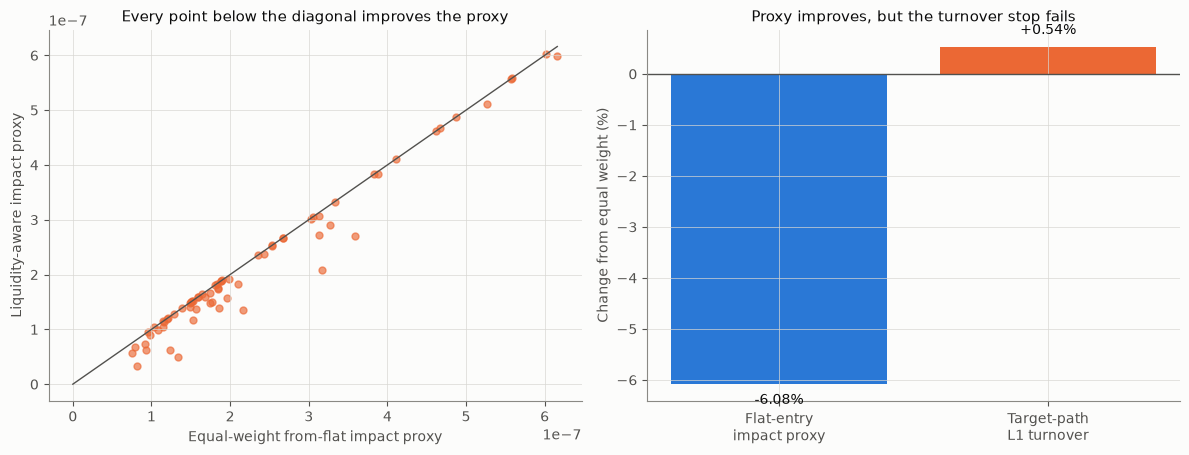

**Input-only NO-GO.** The frozen rule is stopped without constructing modified next-open returns.

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
active_audit = target_audit.loc[active].copy()
axes[0].scatter(
    active_audit["equal_flat_entry_impact_proxy"],
    active_audit["optimized_flat_entry_impact_proxy"],
    alpha=0.65,
    color=CATEGORICAL[1],
)
proxy_limit = float(
    max(
        active_audit["equal_flat_entry_impact_proxy"].max(),
        active_audit["optimized_flat_entry_impact_proxy"].max(),
    )
)
axes[0].plot([0, proxy_limit], [0, proxy_limit], color=INK["reference"], linewidth=1)
axes[0].set_xlabel("Equal-weight from-flat impact proxy")
axes[0].set_ylabel("Liquidity-aware impact proxy")
axes[0].set_title("Every point below the diagonal improves the proxy")
input_changes = 100.0 * np.asarray(
    [
        input_gate.loc[0, "impact_proxy_change_fraction"],
        input_gate.loc[0, "target_turnover_change_fraction"],
    ]
)
axes[1].bar(
    ["Flat-entry\nimpact proxy", "Target-path\nL1 turnover"],
    input_changes,
    color=[CATEGORICAL[0], CATEGORICAL[1]],
)
axes[1].axhline(0.0, color=INK["reference"], linewidth=1)
for index, value in enumerate(input_changes):
    axes[1].text(
        index,
        value + (0.18 if value >= 0 else -0.18),
        f"{value:+.2f}%",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=10,
    )
axes[1].set_ylabel("Change from equal weight (%)")
axes[1].set_title("Proxy improves, but the turnover stop fails")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "input_only_impact_and_turnover.png", dpi=180, bbox_inches="tight")
plt.show()

if input_gate_pass:
    display(Markdown("**Input gate PASS.** Modified forward returns may now be constructed."))
else:
    display(
        Markdown(
            "**Input-only NO-GO.** The frozen rule is stopped without constructing modified "
            "next-open returns."
        )
    )

## Conditional outcome evaluation

This section runs only if the displayed input gate passes. At both frozen AUM
references, liquidity-aware and equal-weight targets receive identical fixed and
impact assumptions. Their two paired net-return comparisons form one BH family.
`Y=0` is reported only to separate changed portfolio returns from estimated impact
savings; it is not a selectable cost scenario.

In [4]:
results = pd.DataFrame()
paired_inference = pd.DataFrame()
temporal = pd.DataFrame()
gates = pd.DataFrame(
    [
        {
            "input_gate_pass": input_gate_pass,
            "primary_implementation_gate": False,
            "capacity_extension_gate": False,
            "promotion_gate": False,
        }
    ]
)
simulations: dict[tuple[str, float, float], object] = {}

if input_gate_pass:
    open_wide = prices.pivot(index="session_date", columns="symbol", values="open").sort_index().dropna()
    locations = open_wide.index.get_indexer(sessions)
    if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
        raise ValueError("signal sessions are not consecutive complete-price sessions")
    if locations[-1] + 1 >= len(open_wide):
        raise ValueError("last signal session has no next open")
    return_rows: list[OpenToOpenReturn] = []
    for session, location in zip(sessions, locations, strict=True):
        next_session = open_wide.index[location + 1]
        values = (
            open_wide.loc[next_session, list(symbols)]
            / open_wide.loc[session, list(symbols)]
            - 1.0
        )
        for symbol, value in values.items():
            return_rows.append(
                OpenToOpenReturn(
                    symbol=symbol,
                    session=str(session.date()),
                    next_session=str(next_session.date()),
                    value=float(value),
                )
            )
    input_gate.loc[0, "returns_constructed"] = True

    result_rows: list[dict[str, object]] = []
    for allocation, targets in (
        ("equal_weight", equal_targets),
        ("liquidity_aware", optimized_targets),
    ):
        for initial_aum in EVALUATION_AUM:
            for coefficient in IMPACT_SCENARIOS:
                simulation = simulate_square_root_impact(
                    targets,
                    return_rows,
                    liquidity,
                    config=ImpactConfig(
                        fixed_cost_rate_per_side=COST_BPS / 10_000.0,
                        impact_coefficient=coefficient,
                        initial_nav_usd=initial_aum,
                        participation_limit=PARTICIPATION_LIMIT,
                    ),
                )
                simulations[(allocation, initial_aum, coefficient)] = simulation
                result_rows.append(
                    {
                        "allocation": allocation,
                        "initial_aum_usd": initial_aum,
                        "impact_coefficient": coefficient,
                        **summarize_capacity(
                            simulation,
                            participation_limit=PARTICIPATION_LIMIT,
                        ),
                    }
                )
    results = pd.DataFrame(result_rows)

    n51_curve = pd.read_csv(N51_CURVE_PATH)
    reproduction_rows = []
    for initial_aum in EVALUATION_AUM:
        current = results.loc[
            results["allocation"].eq("equal_weight")
            & results["initial_aum_usd"].eq(initial_aum)
            & results["impact_coefficient"].eq(IMPACT_COEFFICIENT)
        ].iloc[0]
        reference = n51_curve.loc[
            n51_curve["initial_aum_usd"].eq(initial_aum)
            & n51_curve["impact_coefficient"].eq(IMPACT_COEFFICIENT)
        ].iloc[0]
        for metric in (
            "sharpe_gross",
            "sharpe_net",
            "total_return_net",
            "maximum_drawdown",
            "total_turnover",
            "mean_impact_bps_per_traded_dollar",
            "maximum_participation",
        ):
            error = abs(float(current[metric]) - float(reference[metric]))
            reproduction_rows.append(
                {"initial_aum_usd": initial_aum, "metric": metric, "absolute_error": error}
            )
    reproduction = pd.DataFrame(reproduction_rows)
    if reproduction["absolute_error"].max() > 1e-10:
        raise RuntimeError("Notebook 51 equal-weight impact reproduction failed")

    comparison_rows = []
    for index, initial_aum in enumerate(EVALUATION_AUM):
        equal_daily = fold_terminal_liquidation(
            simulations[("equal_weight", initial_aum, IMPACT_COEFFICIENT)].daily
        )
        optimized_daily = fold_terminal_liquidation(
            simulations[("liquidity_aware", initial_aum, IMPACT_COEFFICIENT)].daily
        )
        comparison_rows.append(
            {
                "comparison": f"liquidity_aware_minus_equal_{int(initial_aum / 1_000_000)}m",
                "initial_aum_usd": initial_aum,
                **paired_block_bootstrap_difference(
                    optimized_daily,
                    equal_daily,
                    value_col="net_return",
                    block_length=BLOCK_LENGTH,
                    replications=REPLICATIONS,
                    seed=SEED + index,
                ),
            }
        )
    paired_inference = pd.DataFrame(comparison_rows)
    paired_inference["bh_reject_q05"] = multipletests(
        paired_inference["p_two_sided"], alpha=0.05, method="fdr_bh"
    )[0]
    paired_inference["bh_q_value"] = multipletests(
        paired_inference["p_two_sided"], alpha=0.05, method="fdr_bh"
    )[1]

    temporal_rows = []
    midpoint = len(sessions) // 2
    for allocation in ("equal_weight", "liquidity_aware"):
        daily = fold_terminal_liquidation(
            simulations[(allocation, PRIMARY_AUM, IMPACT_COEFFICIENT)].daily
        )
        for period, selector in (
            ("first_half", np.arange(len(daily)) < midpoint),
            ("second_half", np.arange(len(daily)) >= midpoint),
        ):
            selected = daily.loc[selector].reset_index(drop=True)
            net = selected["net_return"]
            temporal_rows.append(
                {
                    "allocation": allocation,
                    "period": period,
                    "n_sessions": len(selected),
                    "active_sessions": int(selected["gross_exposure"].gt(0).sum()),
                    "sharpe_net": annualized_sharpe(net),
                    "total_return_net": float((1.0 + net).prod() - 1.0),
                }
            )
    temporal = pd.DataFrame(temporal_rows)

    indexed = results.set_index(["allocation", "initial_aum_usd", "impact_coefficient"])
    primary_equal = indexed.loc[("equal_weight", PRIMARY_AUM, IMPACT_COEFFICIENT)]
    primary_optimized = indexed.loc[("liquidity_aware", PRIMARY_AUM, IMPACT_COEFFICIENT)]
    extension_equal = indexed.loc[("equal_weight", EXTENSION_AUM, IMPACT_COEFFICIENT)]
    extension_optimized = indexed.loc[("liquidity_aware", EXTENSION_AUM, IMPACT_COEFFICIENT)]
    primary_test = paired_inference.set_index("initial_aum_usd").loc[PRIMARY_AUM]
    extension_test = paired_inference.set_index("initial_aum_usd").loc[EXTENSION_AUM]
    gates = pd.DataFrame(
        [
            {
                "input_gate_pass": input_gate_pass,
                "primary_implementation_gate": bool(
                    primary_optimized["total_return_net"] > 0
                    and primary_optimized["sharpe_net"] > 0
                    and primary_optimized["mean_impact_bps_per_traded_dollar"]
                    < primary_equal["mean_impact_bps_per_traded_dollar"]
                    and primary_test["mean_difference"] > 0
                    and primary_test["bh_reject_q05"]
                ),
                "capacity_extension_gate": bool(
                    extension_optimized["total_return_net"] > 0
                    and extension_optimized["sharpe_net"] > 0
                    and extension_optimized["all_orders_within_participation_limit"]
                    and extension_test["mean_difference"] > 0
                    and extension_test["bh_reject_q05"]
                ),
                "primary_equal_net_sharpe": float(primary_equal["sharpe_net"]),
                "primary_liquidity_aware_net_sharpe": float(primary_optimized["sharpe_net"]),
                "primary_equal_net_return": float(primary_equal["total_return_net"]),
                "primary_liquidity_aware_net_return": float(
                    primary_optimized["total_return_net"]
                ),
                "primary_equal_impact_bps": float(
                    primary_equal["mean_impact_bps_per_traded_dollar"]
                ),
                "primary_liquidity_aware_impact_bps": float(
                    primary_optimized["mean_impact_bps_per_traded_dollar"]
                ),
                "primary_difference_bps_session": float(
                    primary_test["mean_difference"] * 10_000.0
                ),
                "primary_difference_ci_low_bps_session": float(
                    primary_test["ci_low"] * 10_000.0
                ),
                "primary_difference_ci_high_bps_session": float(
                    primary_test["ci_high"] * 10_000.0
                ),
                "primary_difference_bh_q": float(primary_test["bh_q_value"]),
                "extension_equal_net_sharpe": float(extension_equal["sharpe_net"]),
                "extension_liquidity_aware_net_sharpe": float(
                    extension_optimized["sharpe_net"]
                ),
                "extension_liquidity_aware_net_return": float(
                    extension_optimized["total_return_net"]
                ),
                "extension_liquidity_aware_max_participation": float(
                    extension_optimized["maximum_participation"]
                ),
                "extension_liquidity_aware_breaching_orders": int(
                    extension_optimized["orders_over_participation_limit"]
                ),
                "extension_difference_bps_session": float(
                    extension_test["mean_difference"] * 10_000.0
                ),
                "extension_difference_bh_q": float(extension_test["bh_q_value"]),
                "promotion_gate": False,
            }
        ]
    )
    display(results)
    display(reproduction)
    display(paired_inference)
    display(temporal)
    display(gates.T)
else:
    reproduction = pd.DataFrame()
    display(gates.T)

,0
input_gate_pass,False
primary_implementation_gate,False
capacity_extension_gate,False
promotion_gate,False


## Outcome figures when the input gate passes

The left panel compares impact-adjusted wealth at the primary $10m reference. The
right panel separates fixed-cost-only and impact-adjusted net Sharpe at both frozen
AUM points. If the input gate fails, no outcome figure is produced.

In [5]:
if input_gate_pass:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
    for index, allocation in enumerate(("equal_weight", "liquidity_aware")):
        daily = fold_terminal_liquidation(
            simulations[(allocation, PRIMARY_AUM, IMPACT_COEFFICIENT)].daily
        )
        label = "Equal weight" if allocation == "equal_weight" else "Liquidity aware"
        axes[0].plot(
            daily["session_date"],
            (1.0 + daily["net_return"]).cumprod(),
            linewidth=2.1,
            color=CATEGORICAL[index],
            label=label,
        )
    axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8, alpha=0.5)
    axes[0].set_xlabel("Signal session")
    axes[0].set_ylabel("Net wealth")
    axes[0].set_title("Primary $10m, fixed cost plus Y=1 impact")
    axes[0].legend(frameon=False)

    plot_results = results.copy()
    x = np.arange(len(EVALUATION_AUM))
    width = 0.18
    offsets = {
        ("equal_weight", 0.0): -1.5 * width,
        ("liquidity_aware", 0.0): -0.5 * width,
        ("equal_weight", 1.0): 0.5 * width,
        ("liquidity_aware", 1.0): 1.5 * width,
    }
    colors = {
        ("equal_weight", 0.0): CATEGORICAL[0],
        ("liquidity_aware", 0.0): CATEGORICAL[1],
        ("equal_weight", 1.0): CATEGORICAL[2],
        ("liquidity_aware", 1.0): CATEGORICAL[3],
    }
    for key, offset in offsets.items():
        allocation, coefficient = key
        group = (
            plot_results.loc[
                plot_results["allocation"].eq(allocation)
                & plot_results["impact_coefficient"].eq(coefficient)
            ]
            .set_index("initial_aum_usd")
            .reindex(EVALUATION_AUM)
        )
        axes[1].bar(
            x + offset,
            group["sharpe_net"],
            width,
            color=colors[key],
            label=(
                ("Equal" if allocation == "equal_weight" else "Liquidity")
                + (", fixed only" if coefficient == 0 else ", + impact")
            ),
        )
    axes[1].axhline(0.0, color=INK["reference"], linewidth=0.9)
    axes[1].set_xticks(x, ["$10m", "$25m"])
    axes[1].set_ylabel("Net Sharpe")
    axes[1].set_title("Return change versus impact saving")
    axes[1].legend(frameon=False, fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "liquidity_sizing_outcomes.png", dpi=180, bbox_inches="tight")
    plt.show()

## Persisted aggregate evidence and interpretation boundary

Aggregate input diagnostics are always saved. Outcome tables and drift-aware paths
exist only when the frozen input gate passes. No headline text or proprietary story
payload is loaded or emitted.

In [6]:
input_gate.to_csv(OUTPUT_DIR / "input_gate.csv", index=False)
target_audit.to_csv(OUTPUT_DIR / "target_audit.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
paired_inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
if input_gate_pass:
    reproduction.to_csv(OUTPUT_DIR / "n51_reproduction.csv", index=False)
    for allocation in ("equal_weight", "liquidity_aware"):
        for initial_aum in EVALUATION_AUM:
            slug = f"{allocation}_{int(initial_aum / 1_000_000)}m"
            simulation = simulations[(allocation, initial_aum, IMPACT_COEFFICIENT)]
            fold_terminal_liquidation(simulation.daily).to_parquet(
                OUTPUT_DIR / f"{slug}_daily.parquet", index=False
            )
            simulation.orders.to_parquet(OUTPUT_DIR / f"{slug}_orders.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": (
        "RETROSPECTIVE_OPENED_WINDOW_LIQUIDITY_SIZING_AUDIT"
        if input_gate_pass
        else "INPUT_ONLY_LIQUIDITY_SIZING_NO_GO"
    ),
    "notebook": "52_lseg_gemma_hybrid_liquidity_aware_sizing.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma_aggregate_panel": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "finbert_aggregate_panel": str(FINBERT_PATH.relative_to(REPO_ROOT)),
        "price_path": str(PRICE_PATH.relative_to(REPO_ROOT)),
        "notebook51_curve": str(N51_CURVE_PATH.relative_to(REPO_ROOT)),
        "frozen_spec": str(FROZEN_SPEC_PATH.relative_to(REPO_ROOT)),
        "licensed_headline_text_loaded": False,
        "source_regimes_pooled": False,
    },
    "specification": frozen_spec,
    "input_gate": json.loads(input_gate.to_json(orient="records"))[0],
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(paired_inference.to_json(orient="records")),
    "temporal": json.loads(temporal.to_json(orient="records")),
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "limitations": frozen_spec["limitations"]
    + [
        "The liquidity-aware allocation was designed after Notebook 51 exposed the capacity result.",
        "No result can promote the strategy or supersede the prospective post-2026-06-26 contract.",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "INPUT_ONLY_LIQUIDITY_SIZING_NO_GO",
  "notebook": "52_lseg_gemma_hybrid_liquidity_aware_sizing.ipynb",
  "git_commit_at_execution": "d92acd136aed0828a617b58ccab5cb346ba695a9",
  "seed": 20260814,
  "input": {
    "gemma_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "finbert_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/finbert_firm_open_aggregators.parquet",
    "price_path": "Data/derived/prices/lseg_us_sector_33_8m.csv",
    "notebook51_curve": "final_experiments/outputs/51_lseg_gemma_hybrid_implementation_capacity/capacity_curve.csv",
    "frozen_spec": "final_experiments/frozen_specs/lseg_gemma_hybrid_liquidity_sizing_v1.json",
    "licensed_headline_text_loaded": false,
    "source_regimes_pooled": false
  },
  "specification": {
    "experiment_id": "N52_lseg_gemma_hybrid_liquidity_sizing_v1",
    "frozen_at": "2026-08-06",
    "status": "frozen_before_modified_targ

## Interpretation

The frozen input gate stops the rule. It preserves all 70 Gemma event sessions,
every FinBERT-selected name and sign, both leg budgets, exact neutrality, and the 25%
cap. The analytical allocation lowers the aggregate from-flat impact proxy by 6.08%,
but target-path L1 turnover rises 0.54%, from 74.458 to 74.858. That violates the
predeclared no-higher-turnover condition because the optimizer ignores drifted
rebalances and allows liquidity weights to move between sessions.

No modified next-open return was constructed. Preserve this as a clean input-only
NO-GO: a daily liquidity/volatility reweight is not a credible repair of Notebook 51's
capacity bottleneck under the frozen rule. Do not smooth, shrink, or tune it on this
opened window. The equal-weight hybrid remains the prospective candidate, and only
genuinely new dates can change its evidential status.